Part (a): Gradient Boosting — 500 rounds
  Best test accuracy : 0.8889  at round 7
  Final test accuracy: 0.8333  (round 500)
  Overfitting observed: True
  Test accuracy starts declining around round ~1

Part (b): Random Forest (from Problem 2d)
RF accuracies: ['0.856', '0.844', '0.844', '0.889', '0.867', '0.867', '0.867']


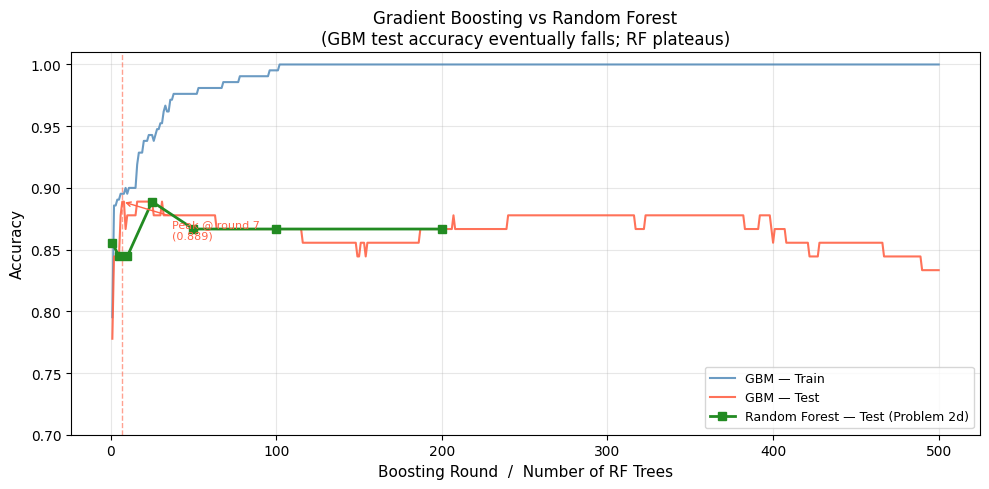

In [3]:
# Problem 3: Gradient Boosting and Overfitting


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Same dataset & split as Problem 2 
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)


# PART (a): Boosting learning curves

gb = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=0
)
gb.fit(X_train, y_train)

# staged_predict returns predictions after each boosting round
train_accs = []
test_accs  = []

for y_train_pred, y_test_pred in zip(
    gb.staged_predict(X_train),
    gb.staged_predict(X_test)
):
    train_accs.append(accuracy_score(y_train, y_train_pred))
    test_accs.append(accuracy_score(y_test,  y_test_pred))

rounds = np.arange(1, 501)

# Find where test accuracy peaks
best_round    = np.argmax(test_accs) + 1
best_test_acc = test_accs[best_round - 1]

print("=" * 55)
print("Part (a): Gradient Boosting — 500 rounds")
print("=" * 55)
print(f"  Best test accuracy : {best_test_acc:.4f}  at round {best_round}")
print(f"  Final test accuracy: {test_accs[-1]:.4f}  (round 500)")

overfit = test_accs[-1] < best_test_acc - 0.005
print(f"  Overfitting observed: {overfit}")
if overfit:
    drop_round = next(
        i + 1 for i, a in enumerate(test_accs) if a < best_test_acc - 0.005
    )
    print(f"  Test accuracy starts declining around round ~{drop_round}")

# PART (b): Random Forest comparison (from Problem 2)


B_values = [1, 5, 10, 25, 50, 100, 200]
rf_accs  = []

for B in B_values:
    rf = RandomForestClassifier(n_estimators=B, max_features='sqrt', random_state=0)
    rf.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf.predict(X_test)))

print("\n" + "=" * 55)
print("Part (b): Random Forest (from Problem 2d)")
print("=" * 55)
print("RF accuracies:", [f"{a:.3f}" for a in rf_accs])

# ── Combined plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(rounds, train_accs, color='steelblue', lw=1.5, alpha=0.8, label='GBM — Train')
ax.plot(rounds, test_accs,  color='tomato',    lw=1.5, alpha=0.9, label='GBM — Test')

ax.axvline(best_round, color='tomato', lw=1, linestyle='--', alpha=0.6)
ax.annotate(
    f'Peak @ round {best_round}\n({best_test_acc:.3f})',
    xy=(best_round, best_test_acc),
    xytext=(best_round + 30, best_test_acc - 0.03),
    fontsize=8, color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1)
)

ax.plot(B_values, rf_accs, color='forestgreen', lw=2,
        marker='s', markersize=6, label='Random Forest — Test (Problem 2d)')

ax.set_xlabel('Boosting Round  /  Number of RF Trees', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(
    'Gradient Boosting vs Random Forest\n'
    '(GBM test accuracy eventually falls; RF plateaus)',
    fontsize=12
)
ax.legend(fontsize=9)
ax.set_ylim(0.70, 1.01)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part (b) — Why GBM overfits but Random Forest does not

In **boosting**, each new tree is fit to the *residual errors* of all previous trees, so every tree is directly coupled to the training data's mistakes. With enough rounds the ensemble starts memorising noise, causing test accuracy to fall — exactly like training a neural net for too many epochs.

In **bagging (Random Forest)**, each tree is trained independently on a bootstrap sample; they vote but do not correct each other. Adding more trees only *averages* independent errors, so variance shrinks toward a floor and test accuracy plateaus — it never rises back up to overfit.

---

### Part (c) — Connection to Gradient Descent

| Concept | Gradient Boosting | Neural Network (SGD) |
|---|---|---|
| One update step | Fit one new tree to $-\nabla\mathcal{L}$ | $w \leftarrow w - \eta \nabla_w \mathcal{L}$ |
| Learning rate | `learning_rate` (shrinkage) | $\eta$ (step size) |
| Number of steps | `n_estimators` | Number of epochs |

In both cases the update direction is the **negative gradient of the loss**:
- GBM fits a tree to the negative gradient of the loss w.r.t. current predictions
- SGD subtracts $\eta \times \nabla_w(\mathcal{L})$ from the weights

The same overfitting risk appears because too many steps (trees / epochs) at too high a rate causes the model to chase training noise rather than generalise. The fix in both cases is **early stopping** or **reducing the step size** (shrinkage / learning rate).